# Dataset bán lẻ kể câu chuyện gì?

## Storytelling EDA — từ một đơn hàng thật đến bài toán dự báo 2023–2024

Notebook này gom các phát hiện thú vị nhất của 14 file nguồn vào **một câu chuyện có thể chạy lại**.
Mỗi chương đi theo nhịp:

> **Câu hỏi → bằng chứng toàn dữ liệu → ý nghĩa business → giới hạn diễn giải**

Câu chuyện chính: một doanh nghiệp thời trang tăng trưởng trong nhiều năm, đổi chế độ vào cuối 2018,
có mùa vụ rất rõ và một “cú twist” tháng 8 năm lẻ. Nhưng chính dữ liệu cũng đặt ra ranh giới:
không phải correlation nào cũng là conversion, không phải anomaly nào cũng là lỗi, và không có bảng phụ nào
cho ta nhìn thấy tương lai sau ngày 31/12/2022.


## 0. Quy ước đọc notebook

- **Quan sát**: số đo trực tiếp từ dữ liệu.
- **Diễn giải**: ý nghĩa hợp lý rút ra từ quan sát.
- **Giả thuyết**: cách giải thích cần thêm dữ liệu hoặc kiểm chứng.
- **Không được kết luận**: điều dataset hiện tại không đủ sức chứng minh.

Dataset không công bố đơn vị tiền tệ, múi giờ, SLA giao hàng hay định nghĩa kế toán chính thức.
Vì vậy notebook không tự gán VND/USD và không gọi Gross Profit là lợi nhuận cuối cùng.

> **Cách chạy:** chọn **Run All** để chạy từ trên xuống. Cell đầu tiên chỉ import và cấu hình môi trường nên
> không tạo biểu đồ; biểu đồ đầu tiên xuất hiện ở Chương 4. File này cũng đã lưu sẵn toàn bộ output.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

# pandas.DataFrame.style cần jinja2, nhưng requirements.txt không cài gói này.
# Fallback dưới đây giữ bảng đọc được mà không thêm dependency ngoài project.
try:
    import jinja2  # noqa: F401
except ImportError:
    class PlainStyler:
        def __init__(self, frame):
            self.frame, self.formatters, self.show_index = frame, None, True
        def format(self, formatters=None, **kwargs):
            self.formatters = formatters
            return self
        def hide(self, axis='index', **kwargs):
            if axis == 'index': self.show_index = False
            return self
        def _repr_html_(self):
            def as_callable(fmt):
                return (lambda value: fmt.format(value)) if isinstance(fmt, str) else fmt
            fmts = self.formatters
            if isinstance(fmts, dict):
                fmts = {col: as_callable(fmt) for col, fmt in fmts.items()}
            elif isinstance(fmts, str):
                fmts = [as_callable(fmts) for _ in self.frame.columns]
            return self.frame.to_html(index=self.show_index, formatters=fmts, border=0)
    pd.DataFrame.style = property(lambda frame: PlainStyler(frame))

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
C = {'blue':'#2878B5', 'orange':'#F28E2B', 'green':'#59A14F',
     'red':'#E15759', 'purple':'#8E6CBA', 'grey':'#6B7280'}
DATA = Path('data')
assert DATA.exists(), "Thiếu thư mục data/ ở root repo. Xem README.md để tải đủ 14 file nguồn."
print('Khởi tạo thành công. Cell này chỉ chuẩn bị môi trường nên không có biểu đồ.')


Khởi tạo thành công. Cell này chỉ chuẩn bị môi trường nên không có biểu đồ.


## 1. Mở kho dữ liệu: 14 lát cắt của cùng một doanh nghiệp

```text
Khu vực → Khách hàng → Đơn hàng → Dòng hàng ← Sản phẩm
                                  ↓
                              Khuyến mãi
                    Đơn hàng → Thanh toán/Giao hàng
                    Dòng hàng → Hoàn trả/Đánh giá
                    Sản phẩm → Snapshot tồn kho
                    Ngày → Web traffic/Sales actual/Forecast
```

Trước KPI hay biểu đồ, câu hỏi đầu tiên là: **một dòng của mỗi file đại diện cho cái gì?**


In [2]:
source_files = [
    'customers', 'geography', 'products', 'promotions', 'orders', 'order_items',
    'payments', 'shipments', 'returns', 'reviews', 'inventory', 'web_traffic',
    'sales', 'sample_submission'
]
sources = {name: pd.read_csv(DATA / f'{name}.csv', low_memory=False) for name in source_files}
for table, cols in {
    'customers':['signup_date'], 'promotions':['start_date','end_date'],
    'orders':['order_date'], 'shipments':['ship_date','delivery_date'],
    'returns':['return_date'], 'reviews':['review_date'],
    'inventory':['snapshot_date'], 'web_traffic':['date'],
    'sales':['Date'], 'sample_submission':['Date']
}.items():
    for col in cols:
        sources[table][col] = pd.to_datetime(sources[table][col])

grain = {
    'customers':'1 khách hàng', 'geography':'1 mã zip', 'products':'1 SKU/biến thể',
    'promotions':'1 chương trình', 'orders':'1 đơn hàng', 'order_items':'1 dòng hàng',
    'payments':'1 thanh toán của đơn', 'shipments':'1 lô giao của đơn',
    'returns':'1 lần trả dòng hàng', 'reviews':'1 đánh giá dòng hàng',
    'inventory':'1 snapshot tháng × SKU', 'web_traffic':'1 ngày',
    'sales':'1 ngày actual', 'sample_submission':'1 ngày cần dự báo'
}
keys = {
    'customers':'customer_id', 'geography':'zip', 'products':'product_id', 'promotions':'promo_id',
    'orders':'order_id', 'order_items':'nguồn thiếu khóa dòng', 'payments':'order_id',
    'shipments':'order_id', 'returns':'return_id', 'reviews':'review_id',
    'inventory':'snapshot_date + product_id', 'web_traffic':'date',
    'sales':'Date', 'sample_submission':'Date'
}
inventory_table = pd.DataFrame({
    'source':source_files, 'rows':[len(sources[x]) for x in source_files],
    'columns':[sources[x].shape[1] for x in source_files],
    'grain':[grain[x] for x in source_files], 'key':[keys[x] for x in source_files]
})
display(inventory_table.style.format({'rows':'{:,.0f}'}).hide(axis='index'))
print(f"Đã đọc {len(source_files)}/14 nguồn — tổng cộng {inventory_table.rows.sum():,} dòng.")


source,rows,columns,grain,key
customers,"121,930",7,1 khách hàng,customer_id
geography,"39,948",4,1 mã zip,zip
products,"2,412",8,1 SKU/biến thể,product_id
promotions,50,10,1 chương trình,promo_id
orders,"646,945",8,1 đơn hàng,order_id
order_items,"714,669",7,1 dòng hàng,nguồn thiếu khóa dòng
payments,"646,945",4,1 thanh toán của đơn,order_id
shipments,"566,067",4,1 lô giao của đơn,order_id
returns,"39,939",7,1 lần trả dòng hàng,return_id
reviews,"113,551",7,1 đánh giá dòng hàng,review_id


Đã đọc 14/14 nguồn — tổng cộng 2,960,736 dòng.


**Chốt chương 1.** Xương sống là `orders → order_items`. Các bảng còn lại giải thích ai mua, mua gì,
ở đâu, được khuyến mãi thế nào, thanh toán/giao/hoàn trả ra sao và kết quả cuối ngày là bao nhiêu.


## 2. Theo chân một đơn hàng thật

Ta chọn `order_id = 46270`. Một giao dịch thật cho thấy grain và vai trò của các bảng rõ hơn một sơ đồ trừu tượng.


In [3]:
customers, geography = sources['customers'], sources['geography']
products, promotions = sources['products'], sources['promotions']
orders, payments = sources['orders'], sources['payments']
shipments, returns, reviews = sources['shipments'], sources['returns'], sources['reviews']
inventory, traffic = sources['inventory'], sources['web_traffic']
sales, submission = sources['sales'].copy(), sources['sample_submission'].copy()
items = sources['order_items'].copy()

# Quy tắc tái dựng có thể lặp lại, không phải khóa gốc từ source.
items['line_number'] = items.groupby('order_id').cumcount() + 1
item_fact = (items
    .merge(orders[['order_id','order_date','customer_id','zip','order_status',
                   'payment_method','device_type','order_source']],
           on='order_id', how='left', validate='many_to_one')
    .merge(products[['product_id','product_name','category','segment','price','cogs']],
           on='product_id', how='left', validate='many_to_one'))
item_fact['gross_revenue'] = item_fact.quantity * item_fact.unit_price
item_fact['net_sales'] = item_fact.gross_revenue - item_fact.discount_amount
item_fact['cogs_amount'] = item_fact.quantity * item_fact.cogs
item_fact['gross_profit'] = item_fact.net_sales - item_fact.cogs_amount

ORDER_ID = 46270
o = orders.loc[orders.order_id.eq(ORDER_ID)].iloc[0]
li = item_fact.loc[item_fact.order_id.eq(ORDER_ID)]
p = payments.loc[payments.order_id.eq(ORDER_ID)].iloc[0]
sh = shipments.loc[shipments.order_id.eq(ORDER_ID)]
rv = reviews.loc[reviews.order_id.eq(ORDER_ID)]
rt = returns.loc[returns.order_id.eq(ORDER_ID)]
region = geography.loc[geography.zip.eq(o['zip']), 'region'].iloc[0]

story = pd.DataFrame([
    ('1. Khách và nơi mua', f"customer_id={o.customer_id}, region={region}", 'customers + geography'),
    ('2. Đặt đơn', f"{o.order_date.date()}, status={o.order_status}", 'orders'),
    ('3. Chọn sản phẩm', f"{int(li.quantity.sum())} units — {li.product_name.iloc[0]}", 'order_items + products'),
    ('4. Giá tại giao dịch', f"Gross={li.gross_revenue.sum():,.2f}", 'order_items'),
    ('5. Khuyến mãi', f"Discount={li.discount_amount.sum():,.2f}", 'order_items + promotions'),
    ('6. Thanh toán', f"{p.payment_method}, {int(p.installments)} kỳ, Net={p.payment_value:,.2f}", 'payments'),
    ('7. Giao hàng', 'Không có shipment' if sh.empty else f"{sh.ship_date.iloc[0].date()} → {sh.delivery_date.iloc[0].date()}", 'shipments'),
    ('8. Sau mua', f"{len(rt)} return, {len(rv)} review" + (f", rating={rv.rating.iloc[0]}" if len(rv) else ''), 'returns + reviews')
], columns=['Bước','Bằng chứng của order 46270','Nguồn'])
display(story.style.hide(axis='index'))

money = pd.DataFrame({
    'Khoản':['Gross Revenue','Discount','Net Payment','COGS','Gross Profit sau discount'],
    'Giá trị':[li.gross_revenue.sum(), li.discount_amount.sum(), p.payment_value,
               li.cogs_amount.sum(), li.gross_profit.sum()]
})
display(money.style.format({'Giá trị':'{:,.2f}'}).hide(axis='index'))


Bước,Bằng chứng của order 46270,Nguồn
1. Khách và nơi mua,"customer_id=44051, region=East",customers + geography
2. Đặt đơn,"2013-02-04, status=delivered",orders
3. Chọn sản phẩm,4 units — VietMotion RP-51,order_items + products
4. Giá tại giao dịch,"Gross=2,462.60",order_items
5. Khuyến mãi,Discount=369.39,order_items + promotions
6. Thanh toán,"paypal, 3 kỳ, Net=2,093.21",payments
7. Giao hàng,2013-02-06 → 2013-02-10,shipments
8. Sau mua,"0 return, 1 review, rating=5",returns + reviews


Khoản,Giá trị
Gross Revenue,"2,462.60"
Discount,369.39
Net Payment,"2,093.21"
COGS,"1,946.72"
Gross Profit sau discount,146.49


**Quan sát.** Giá và discount nằm ở dòng hàng; COGS đơn vị nằm ở sản phẩm; payment/shipment thuộc đơn;
return/review thuộc dòng hàng.

**Giới hạn.** `line_number` là quy tắc tái dựng theo thứ tự nguồn, không phải khóa gốc.
Production cần `order_item_id` ổn định.


## 3. Có thể tin các phép nối và KPI đến đâu?

Một câu chuyện đẹp chỉ đáng tin nếu khóa, quan hệ và phép đối soát đứng vững.


In [4]:
duplicate_pairs = (items.groupby(['order_id','product_id']).size() > 1).sum()
relations = [
    ('orders.customer_id → customers', orders.customer_id.isin(customers.customer_id).eq(False).sum()),
    ('orders.zip → geography', orders.zip.isin(geography.zip).eq(False).sum()),
    ('items.order_id → orders', items.order_id.isin(orders.order_id).eq(False).sum()),
    ('items.product_id → products', items.product_id.isin(products.product_id).eq(False).sum()),
    ('payments.order_id → orders', payments.order_id.isin(orders.order_id).eq(False).sum()),
    ('shipments.order_id → orders', shipments.order_id.isin(orders.order_id).eq(False).sum()),
    ('returns.order_id → orders', returns.order_id.isin(orders.order_id).eq(False).sum()),
    ('reviews.order_id → orders', reviews.order_id.isin(orders.order_id).eq(False).sum()),
    ('inventory.product_id → products', inventory.product_id.isin(products.product_id).eq(False).sum())
]
relation_df = pd.DataFrame(relations, columns=['Quan hệ','Số orphan'])

daily_rebuilt = item_fact.groupby('order_date').agg(
    Revenue_rebuilt=('gross_revenue','sum'), COGS_rebuilt=('cogs_amount','sum')).reset_index()
recon = sales.merge(daily_rebuilt, left_on='Date', right_on='order_date', validate='one_to_one')
order_net = item_fact.groupby('order_id').net_sales.sum()
pay_recon = payments.set_index('order_id').join(order_net.rename('net_rebuilt'))

checks = pd.DataFrame([
    ('Dòng trùng hoàn toàn trong 14 nguồn', sum(df.duplicated().sum() for df in sources.values()), '0 là tốt'),
    ('Cặp (order_id, product_id) bị trùng', int(duplicate_pairs), 'cặp này không phải khóa'),
    ('Orphan trên các quan hệ chính', int(relation_df['Số orphan'].sum()), '0 là tốt'),
    ('Sai lệch max sales.Revenue', (recon.Revenue-recon.Revenue_rebuilt).abs().max(), '0 là khớp'),
    ('Sai lệch max sales.COGS', (recon.COGS-recon.COGS_rebuilt).abs().max(), 'float < 0.01'),
    ('Sai lệch max payment_value', (pay_recon.payment_value-pay_recon.net_rebuilt).abs().max(), '0 là khớp')
], columns=['Kiểm tra','Kết quả','Cách đọc'])
display(checks.style.format({'Kết quả':lambda x: f'{x:,.6f}' if isinstance(x,(float,np.floating)) else f'{x:,}'}).hide(axis='index'))


Kiểm tra,Kết quả,Cách đọc
Dòng trùng hoàn toàn trong 14 nguồn,0.000000,0 là tốt
"Cặp (order_id, product_id) bị trùng",16.000000,cặp này không phải khóa
Orphan trên các quan hệ chính,0.000000,0 là tốt
Sai lệch max sales.Revenue,0.000000,0 là khớp
Sai lệch max sales.COGS,0.004999,float < 0.01
Sai lệch max payment_value,0.000000,0 là khớp


**Chốt chương 3.** Target ngày tái tạo được từ giao dịch và các quan hệ chính không có orphan.
Điểm yếu nằm ở khóa dòng hàng: `(order_id, product_id)` trùng ở 16 cặp, nên không được dùng làm khóa join mù quáng.


## 4. Kinh tế cửa hàng: lớn không đồng nghĩa với lời nhiều

Doanh thu cuộc thi là **gross revenue**, còn tiền thu phản ánh discount. Cần đi qua cây cầu
`Gross → Discount → Net → COGS → Gross Profit`.


KPI,Giá trị,Đơn vị
Đơn hàng,"646,945.000",đơn
Khách có mua,"90,246.000",khách
Sản phẩm bán ra,"3,213,143.000",units
Gross Revenue,16.430,tỷ
Discount,0.750,tỷ
Net Sales,15.681,tỷ
COGS,14.163,tỷ
Gross Profit sau discount,1.517,tỷ
Gross Margin,9.677,%
AOV Net Sales,"24,238.334",đơn vị tiền


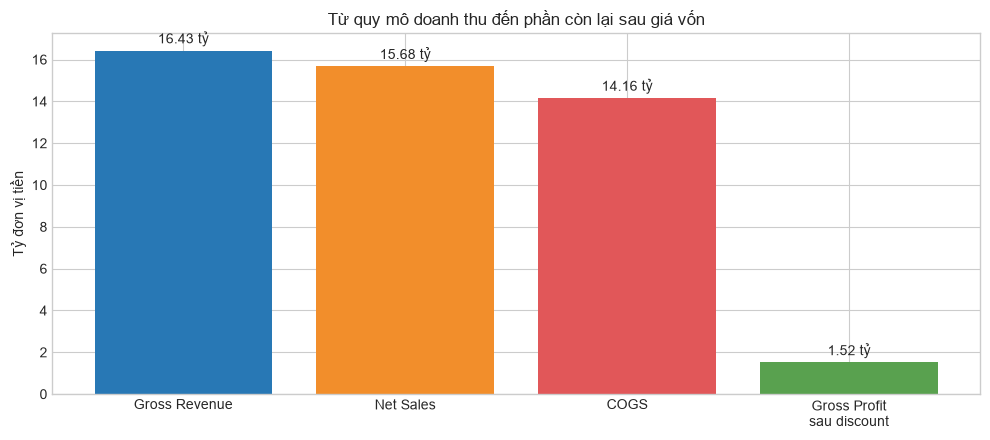

In [5]:
total_orders = orders.order_id.nunique()
total_customers = orders.customer_id.nunique()
total_units = item_fact.quantity.sum()
total_gross = item_fact.gross_revenue.sum()
total_discount = item_fact.discount_amount.sum()
total_net = item_fact.net_sales.sum()
total_cogs = item_fact.cogs_amount.sum()
total_gp = item_fact.gross_profit.sum()

kpis = pd.DataFrame([
    ('Đơn hàng',total_orders,'đơn'), ('Khách có mua',total_customers,'khách'),
    ('Sản phẩm bán ra',total_units,'units'), ('Gross Revenue',total_gross/1e9,'tỷ'),
    ('Discount',total_discount/1e9,'tỷ'), ('Net Sales',total_net/1e9,'tỷ'),
    ('COGS',total_cogs/1e9,'tỷ'), ('Gross Profit sau discount',total_gp/1e9,'tỷ'),
    ('Gross Margin',total_gp/total_net*100,'%'), ('AOV Net Sales',total_net/total_orders,'đơn vị tiền')
], columns=['KPI','Giá trị','Đơn vị'])
display(kpis.style.format({'Giá trị':'{:,.3f}'}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(10,4.5))
labels = ['Gross Revenue','Net Sales','COGS','Gross Profit\nsau discount']
values = np.array([total_gross,total_net,total_cogs,total_gp])/1e9
bars = ax.bar(labels, values, color=[C['blue'],C['orange'],C['red'],C['green']])
ax.bar_label(bars, fmt='%.2f tỷ', padding=3)
ax.set(title='Từ quy mô doanh thu đến phần còn lại sau giá vốn', ylabel='Tỷ đơn vị tiền')
plt.tight_layout(); plt.show()


Gross Revenue khoảng 16,43 tỷ nhưng Gross Profit sau discount chỉ khoảng 1,52 tỷ, margin 9,68%.
COGS chưa gồm shipping, refund, marketing, lương hay OPEX; đây không phải lợi nhuận kế toán cuối cùng.


## 5. Đường tăng trưởng bị bẻ gãy cuối năm 2018

Một tốc độ tăng trưởng trung bình 2013–2022 sẽ trộn hai mặt bằng hoạt động khác nhau vào cùng một con số.
Ở đây, **mặt bằng mới** chỉ có nghĩa là Revenue, số đơn và units sau điểm gãy thấp hơn rõ rệt;
đây là chế độ thống kê quan sát được, không phải chính sách kinh doanh đã được dataset xác nhận.


,2018,2019,Thay đổi %
Revenue,"1,850,122,456.080","1,136,801,441.510",-38.555
Orders,"69,510.000","41,601.000",-40.151
Units,"337,646.000","202,653.000",-39.981


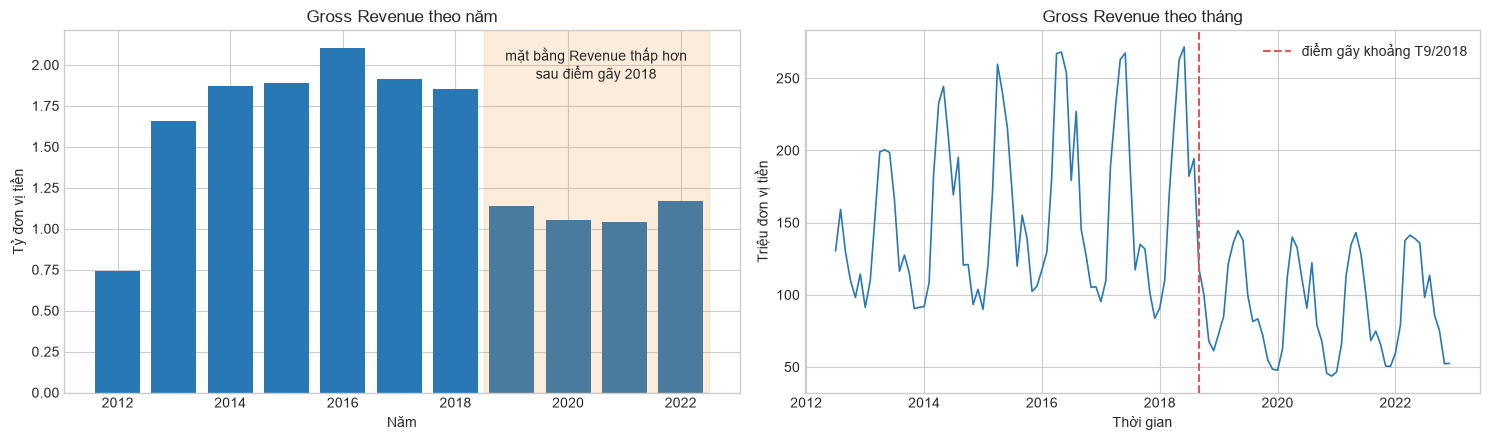

In [6]:
annual = item_fact.assign(year=item_fact.order_date.dt.year).groupby('year').agg(
    Revenue=('gross_revenue','sum'), COGS=('cogs_amount','sum'),
    Orders=('order_id','nunique'), Units=('quantity','sum'))
annual['Revenue_billion'] = annual.Revenue/1e9
break_table = pd.DataFrame({
    '2018':annual.loc[2018,['Revenue','Orders','Units']],
    '2019':annual.loc[2019,['Revenue','Orders','Units']]
})
break_table['Thay đổi %'] = (break_table['2019']/break_table['2018']-1)*100
display(break_table.style.format('{:,.3f}'))

monthly = item_fact.set_index('order_date')[['gross_revenue','cogs_amount']].resample('MS').sum()/1e6
fig, axes = plt.subplots(1,2,figsize=(15,4.5))
axes[0].bar(annual.index, annual.Revenue_billion, color=C['blue'])
axes[0].axvspan(2018.5, 2022.5, color=C['orange'], alpha=.16)
axes[0].text(2020.5, annual.Revenue_billion.max()*.91,
             'mặt bằng Revenue thấp hơn\nsau điểm gãy 2018', ha='center')
axes[0].set(title='Gross Revenue theo năm', ylabel='Tỷ đơn vị tiền', xlabel='Năm')
axes[1].plot(monthly.index, monthly.gross_revenue, lw=1.2, color=C['blue'])
axes[1].axvline(pd.Timestamp('2018-09-01'), color=C['red'], ls='--', label='điểm gãy khoảng T9/2018')
axes[1].set(title='Gross Revenue theo tháng', ylabel='Triệu đơn vị tiền', xlabel='Thời gian')
axes[1].legend()
plt.tight_layout(); plt.show()


Từ 2018 sang 2019, Revenue giảm khoảng 38,56%, số đơn giảm 40,15% và units giảm 39,98%.
Driver trực tiếp là volume; root cause business không có trong dataset. Level/trend nên validation trên chế độ sau 2018.


## 6. Hai chiếc đồng hồ của doanh thu: tháng và ngày trong tháng

Doanh thu có mùa cao/thấp điểm theo tháng và còn tăng mạnh về cuối mỗi tháng.
Thứ trong tuần, trái lại, giải thích rất ít biến thiên.


Nhóm lịch,R² log(Revenue)
Thứ trong tuần,0.0084
Tháng,0.3443
Ngày trong tháng,0.1663
Tháng + ngày,0.6230


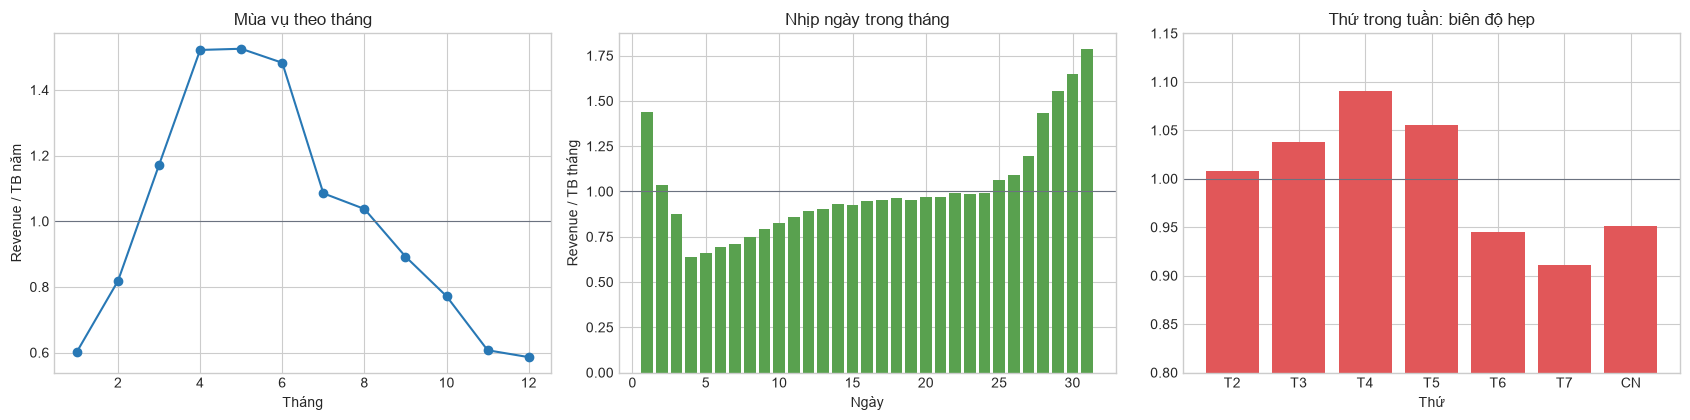

Đỉnh tháng / đáy tháng = 2.60 lần.
Ngày 4 index=0.640; ngày 31 index=1.784.


In [7]:
sales['year'], sales['month'] = sales.Date.dt.year, sales.Date.dt.month
sales['day'], sales['dow'] = sales.Date.dt.day, sales.Date.dt.dayofweek
sales['ratio'] = sales.COGS/sales.Revenue
sales['rev_year_norm'] = sales.Revenue/sales.groupby('year').Revenue.transform('mean')
sales['rev_month_norm'] = sales.Revenue/sales.groupby(['year','month']).Revenue.transform('mean')
month_profile = sales.groupby('month').rev_year_norm.mean()
day_profile = sales.groupby('day').rev_month_norm.mean()
dow_profile = sales.groupby('dow').rev_year_norm.mean()

y = np.log(sales.Revenue.to_numpy())
def grouped_r2(cols):
    pred = sales.assign(_y=y).groupby(cols)._y.transform('mean').to_numpy()
    return 1 - ((y-pred)**2).sum()/((y-y.mean())**2).sum()
r2_table = pd.DataFrame([
    ('Thứ trong tuần',grouped_r2(['dow'])), ('Tháng',grouped_r2(['month'])),
    ('Ngày trong tháng',grouped_r2(['day'])), ('Tháng + ngày',grouped_r2(['month','day']))
], columns=['Nhóm lịch','R² log(Revenue)'])
display(r2_table.style.format({'R² log(Revenue)':'{:.4f}'}).hide(axis='index'))

fig, axes = plt.subplots(1,3,figsize=(17,4.3))
axes[0].plot(month_profile.index,month_profile.values,'o-',color=C['blue'])
axes[0].axhline(1,color=C['grey'],lw=.8); axes[0].set(title='Mùa vụ theo tháng',xlabel='Tháng',ylabel='Revenue / TB năm')
axes[1].bar(day_profile.index,day_profile.values,color=C['green'])
axes[1].axhline(1,color=C['grey'],lw=.8); axes[1].set(title='Nhịp ngày trong tháng',xlabel='Ngày',ylabel='Revenue / TB tháng')
axes[2].bar(['T2','T3','T4','T5','T6','T7','CN'],dow_profile.values,color=C['red'])
axes[2].axhline(1,color=C['grey'],lw=.8); axes[2].set_ylim(.8,1.15)
axes[2].set(title='Thứ trong tuần: biên độ hẹp',xlabel='Thứ')
plt.tight_layout(); plt.show()

print(f"Đỉnh tháng / đáy tháng = {month_profile.max()/month_profile.min():.2f} lần.")
print(f"Ngày 4 index={day_profile.loc[4]:.3f}; ngày 31 index={day_profile.loc[31]:.3f}.")


T4–T6 đạt khoảng 1,48–1,53 lần trung bình năm; T12–T1 chỉ khoảng 0,59–0,60.
`month + day_of_month` đạt R²≈0,623, còn riêng `day_of_week` chỉ ≈0,008.
Đây là mô tả, chưa chứng minh payday hay hành vi cụ thể nào là nguyên nhân.


## 7. Cú twist tháng 8: Urban Blowout chia lịch sử thành năm chẵn và năm lẻ


,So_nam,Revenue_index,Revenue_mean,Units_mean,COGS_Revenue,Price_per_unit
Regime,,,,,,
Năm chẵn,6,1.250,"168,541,210","29,243",0.801,"6,027.04"
Năm lẻ,5,0.782,"100,639,944","29,428",1.345,"3,591.75"


promo_id,promo_name,start_date,end_date,promo_type,discount_value,applicable_category
PROMO-0005,Urban Blowout 2013,2013-07-30,2013-09-02,fixed,50.000,Streetwear
PROMO-0015,Urban Blowout 2015,2015-07-30,2015-09-02,fixed,50.000,Streetwear
PROMO-0025,Urban Blowout 2017,2017-07-30,2017-09-02,fixed,50.000,Streetwear
PROMO-0035,Urban Blowout 2019,2019-07-30,2019-09-02,fixed,50.000,Streetwear
PROMO-0045,Urban Blowout 2021,2021-07-30,2021-09-02,fixed,50.000,Streetwear


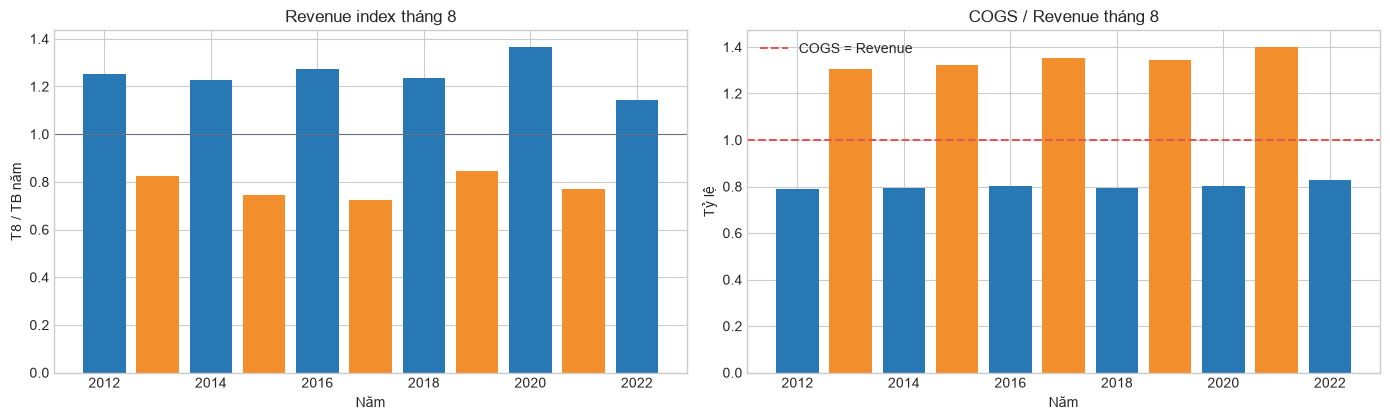

Revenue index năm lẻ thấp hơn năm chẵn -37.44%.
Units bình quân: chẵn 29,243, lẻ 29,428.


In [8]:
aug = (item_fact[item_fact.order_date.dt.month.eq(8)]
       .assign(year=lambda x:x.order_date.dt.year)
       .groupby('year').agg(Revenue=('gross_revenue','sum'), COGS=('cogs_amount','sum'),
                            Units=('quantity','sum')))
aug['Revenue_index'] = sales[sales.month.eq(8)].groupby('year').rev_year_norm.mean()
aug['COGS_Revenue'] = aug.COGS/aug.Revenue
aug['Price_per_unit'] = aug.Revenue/aug.Units
aug['Regime'] = np.where(aug.index%2==0,'Năm chẵn','Năm lẻ')
regime = aug.groupby('Regime').agg(
    So_nam=('Revenue','size'), Revenue_index=('Revenue_index','mean'),
    Revenue_mean=('Revenue','mean'), Units_mean=('Units','mean'),
    COGS_Revenue=('COGS_Revenue','mean'), Price_per_unit=('Price_per_unit','mean'))
display(regime.style.format({
    'Revenue_index':'{:.3f}','Revenue_mean':'{:,.0f}','Units_mean':'{:,.0f}',
    'COGS_Revenue':'{:.3f}','Price_per_unit':'{:,.2f}'}))

urban = promotions[promotions.promo_name.str.contains('Urban Blowout',na=False)]
display(urban[['promo_id','promo_name','start_date','end_date','promo_type',
               'discount_value','applicable_category']].style.hide(axis='index'))

fig, axes = plt.subplots(1,2,figsize=(14,4.3))
bar_colors = [C['blue'] if y%2==0 else C['orange'] for y in aug.index]
axes[0].bar(aug.index,aug.Revenue_index,color=bar_colors)
axes[0].axhline(1,color=C['grey'],lw=.8); axes[0].set(title='Revenue index tháng 8',xlabel='Năm',ylabel='T8 / TB năm')
axes[1].bar(aug.index,aug.COGS_Revenue,color=bar_colors)
axes[1].axhline(1,color=C['red'],ls='--',label='COGS = Revenue')
axes[1].set(title='COGS / Revenue tháng 8',xlabel='Năm',ylabel='Tỷ lệ'); axes[1].legend()
plt.tight_layout(); plt.show()

odd, even = regime.loc['Năm lẻ'], regime.loc['Năm chẵn']
print(f"Revenue index năm lẻ thấp hơn năm chẵn {(odd.Revenue_index/even.Revenue_index-1)*100:.2f}%.")
print(f"Units bình quân: chẵn {even.Units_mean:,.0f}, lẻ {odd.Units_mean:,.0f}.")


Urban Blowout xuất hiện vào 2013, 2015, 2017, 2019, 2021. Units tháng 8 gần như không đổi,
nhưng price/unit năm lẻ giảm mạnh; Revenue index thấp hơn 37,44% và `COGS/Revenue` tăng từ 0,801 lên 1,345.

Promotion đi cùng hiện tượng và cơ chế dữ liệu rất mạnh, nhưng chưa cô lập mọi yếu tố khác.
Dùng cờ Urban Blowout 2023 là một giả định scenario cần backtest.


## 8. Tỷ lệ COGS/Revenue: cấu trúc hấp dẫn, nhưng vẫn phải backtest


,COGS/Revenue trung bình,% ngày COGS > Revenue
month,,
1,0.810,0.6%
2,0.811,0.0%
3,0.845,0.0%
4,0.854,0.0%
5,0.801,0.0%
6,0.836,2.0%
7,0.910,9.8%
8,1.056,45.5%
9,0.891,2.7%


Tương quan ngày Revenue–COGS = 0.9760.


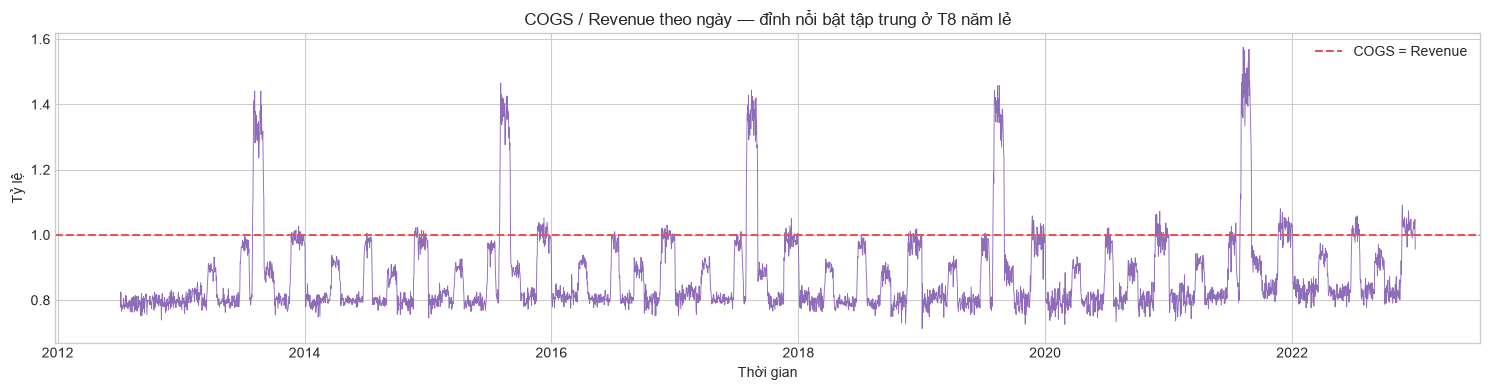

In [9]:
ratio_corr = sales[['Revenue','COGS']].corr().iloc[0,1]
ratio_month = pd.DataFrame({
    'COGS/Revenue trung bình':sales.groupby('month').ratio.mean(),
    '% ngày COGS > Revenue':sales.assign(loss=sales.ratio.gt(1)).groupby('month').loss.mean()*100
})
display(ratio_month.style.format({'COGS/Revenue trung bình':'{:.3f}','% ngày COGS > Revenue':'{:.1f}%'}))
print(f"Tương quan ngày Revenue–COGS = {ratio_corr:.4f}.")

fig,ax=plt.subplots(figsize=(15,4))
ax.plot(sales.Date,sales.ratio,lw=.65,color=C['purple'])
ax.axhline(1,color=C['red'],ls='--',label='COGS = Revenue')
ax.set(title='COGS / Revenue theo ngày — đỉnh nổi bật tập trung ở T8 năm lẻ',
       xlabel='Thời gian',ylabel='Tỷ lệ')
ax.legend(); plt.tight_layout(); plt.show()


Khuyến nghị cần kiểm chứng: so sánh dự báo `Revenue` và `COGS` độc lập với phương án dự báo
`Revenue` cùng `COGS/Revenue`, rồi suy ra COGS bằng rolling-origin backtest.


## 9. Danh mục và thị trường: quy mô không đồng nghĩa với hiệu quả


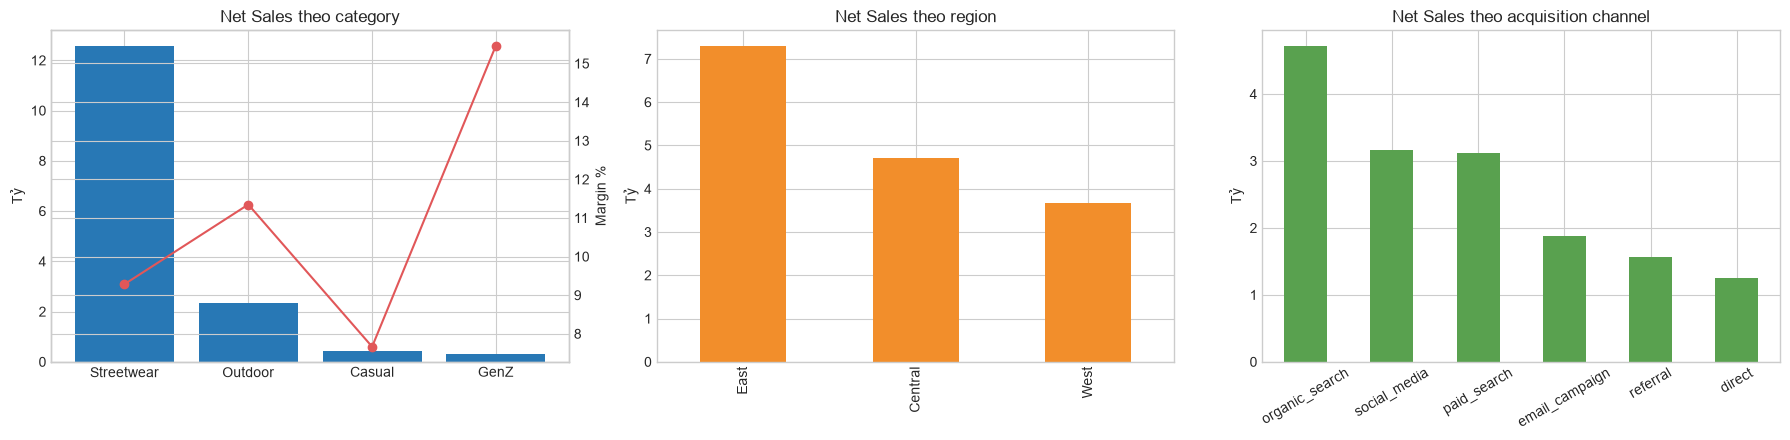

,Net_Sales_billion,Margin_pct,Units,Orders
category,,,,
Streetwear,12.558,9.28%,"1,768,826","389,543"
Outdoor,2.353,11.35%,"1,170,000","200,454"
Casual,0.440,7.66%,"107,469","23,600"
GenZ,0.329,15.47%,"166,848","37,054"


In [10]:
category = item_fact.groupby('category').agg(
    Net_Sales=('net_sales','sum'), Gross_Profit=('gross_profit','sum'),
    Units=('quantity','sum'), Orders=('order_id','nunique'))
category['Margin_pct'] = category.Gross_Profit/category.Net_Sales*100
category = category.sort_values('Net_Sales',ascending=False)

market_fact = (item_fact
    .merge(geography[['zip','region']],on='zip',how='left',validate='many_to_one')
    .merge(customers[['customer_id','acquisition_channel']],on='customer_id',how='left',validate='many_to_one'))
region_sales = market_fact.groupby('region').net_sales.sum().sort_values(ascending=False)/1e9
channel_sales = market_fact.groupby('acquisition_channel').net_sales.sum().sort_values(ascending=False)/1e9

fig, axes=plt.subplots(1,3,figsize=(18,4.5))
x=np.arange(len(category))
axes[0].bar(x,category.Net_Sales/1e9,color=C['blue'])
axes[0].set_xticks(x,category.index); axes[0].set(title='Net Sales theo category',ylabel='Tỷ',xlabel='')
axm=axes[0].twinx(); axm.plot(x,category.Margin_pct,'o-',color=C['red']); axm.set_ylabel('Margin %')
region_sales.plot.bar(ax=axes[1],color=C['orange']); axes[1].set(title='Net Sales theo region',ylabel='Tỷ',xlabel='')
channel_sales.plot.bar(ax=axes[2],color=C['green']); axes[2].set(title='Net Sales theo acquisition channel',ylabel='Tỷ',xlabel='')
axes[2].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()

display(category.assign(Net_Sales_billion=category.Net_Sales/1e9)
        [['Net_Sales_billion','Margin_pct','Units','Orders']]
        .style.format({'Net_Sales_billion':'{:.3f}','Margin_pct':'{:.2f}%','Units':'{:,.0f}','Orders':'{:,.0f}'}))


Streetwear đứng đầu về Net Sales nhưng không đứng đầu về margin; GenZ nhỏ hơn nhưng margin cao hơn.
`acquisition_channel` là thuộc tính hồ sơ khách, không phải attribution chắc chắn của từng order.


## 10. Sau nút “mua”: giao hàng, hoàn trả và đánh giá


Chỉ số,Giá trị,Đơn vị
Order không có shipment,"80,878.000",order
Lead time trung bình,4.499,ngày
Lead time median,4.000,ngày
Return line rate,5.588,%
Return unit rate,3.411,%
Refund / Net Sales,3.256,%
Rating trung bình,3.936,/5


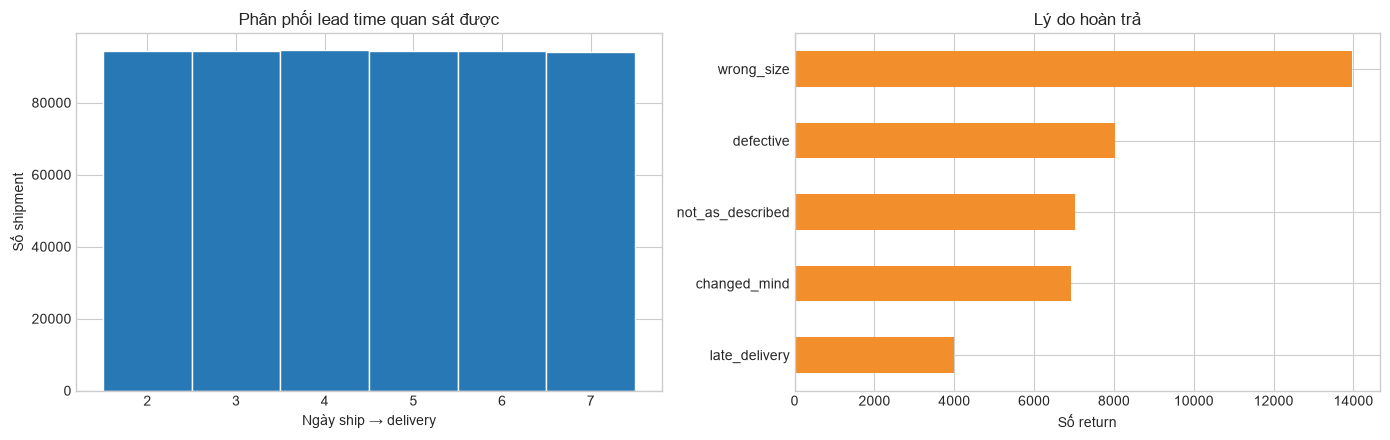

In [11]:
ship = shipments.dropna(subset=['ship_date','delivery_date']).copy()
ship['lead_days'] = (ship.delivery_date-ship.ship_date).dt.days
missing_shipments = orders.order_id.nunique()-shipments.order_id.nunique()
return_line_rate = len(returns)/len(items)*100
return_unit_rate = returns.return_quantity.sum()/items.quantity.sum()*100
refund_net_rate = returns.refund_amount.sum()/total_net*100
ops = pd.DataFrame([
    ('Order không có shipment',missing_shipments,'order'),
    ('Lead time trung bình',ship.lead_days.mean(),'ngày'),
    ('Lead time median',ship.lead_days.median(),'ngày'),
    ('Return line rate',return_line_rate,'%'),
    ('Return unit rate',return_unit_rate,'%'),
    ('Refund / Net Sales',refund_net_rate,'%'),
    ('Rating trung bình',reviews.rating.mean(),'/5')
],columns=['Chỉ số','Giá trị','Đơn vị'])
display(ops.style.format({'Giá trị':'{:,.3f}'}).hide(axis='index'))

fig, axes=plt.subplots(1,2,figsize=(14,4.5))
axes[0].hist(ship.lead_days,bins=np.arange(ship.lead_days.min(),ship.lead_days.max()+2)-.5,
             color=C['blue'],edgecolor='white')
axes[0].set(title='Phân phối lead time quan sát được',xlabel='Ngày ship → delivery',ylabel='Số shipment')
returns.return_reason.value_counts().sort_values().plot.barh(ax=axes[1],color=C['orange'])
axes[1].set(title='Lý do hoàn trả',xlabel='Số return',ylabel='')
plt.tight_layout(); plt.show()


Chưa thể gọi shipment là “trễ” vì không có SLA/promised date.
`order_status='returned'` và event trong returns cũng không nhất thiết là cùng một định nghĩa KPI.


## 11. Những plot twist về chất lượng dữ liệu

Dữ liệu sạch về PK/FK không có nghĩa mọi cột đều đúng nghĩa business.


In [12]:
customer_orders = orders[['order_id','order_date','customer_id']].merge(
    customers[['customer_id','signup_date']],on='customer_id',how='left',validate='many_to_one')
orders_before_signup = customer_orders.order_date.lt(customer_orders.signup_date).mean()*100
cheap_skus = products[products.price.lt(100)]
cheap_sold = cheap_skus.product_id.isin(items.product_id.unique()).sum()
latest_inv = inventory[inventory.snapshot_date.eq(inventory.snapshot_date.max())]
both_flags = (latest_inv.stockout_flag.eq(1) & latest_inv.overstock_flag.eq(1)).mean()*100
monthly_units = (item_fact.assign(snapshot_date=item_fact.order_date + pd.offsets.MonthEnd(0))
                 .groupby(['snapshot_date','product_id']).quantity.sum().rename('transaction_units'))
inv_compare = inventory.set_index(['snapshot_date','product_id']).join(monthly_units)
inventory_match = inv_compare.units_sold.eq(inv_compare.transaction_units).mean()*100

anomalies = pd.DataFrame([
    ('Đơn trước signup_date',f'{orders_before_signup:.2f}% số order','không dùng signup_date cho tenure/cohort'),
    ('products.price < 100',f'{len(cheap_skus):,} SKU; {cheap_sold} SKU từng bán','catalog price không phải lịch sử giá'),
    ('Vừa stockout vừa overstock',f'{both_flags:.2f}% SKU ở snapshot cuối','có thể là cờ khác thời điểm/công thức'),
    ('inventory.units_sold khớp giao dịch',f'{inventory_match:.2f}% snapshot','hai measure có thể khác định nghĩa/kỳ'),
    ('Order thiếu shipment',f'{missing_shipments:,} order','đọc cùng order_status, không mặc định mất dữ liệu')
],columns=['Plot twist','Bằng chứng','Cách dùng đúng'])
display(anomalies.style.hide(axis='index'))
print('Order thiếu shipment theo status:')
display(orders[~orders.order_id.isin(shipments.order_id)].order_status.value_counts()
        .rename('Số order').to_frame().style.format('{:,.0f}'))


Plot twist,Bằng chứng,Cách dùng đúng
Đơn trước signup_date,73.80% số order,không dùng signup_date cho tenure/cohort
products.price < 100,654 SKU; 0 SKU từng bán,catalog price không phải lịch sử giá
Vừa stockout vừa overstock,54.72% SKU ở snapshot cuối,có thể là cờ khác thời điểm/công thức
inventory.units_sold khớp giao dịch,2.85% snapshot,hai measure có thể khác định nghĩa/kỳ
Order thiếu shipment,"80,878 order","đọc cùng order_status, không mặc định mất dữ liệu"


Order thiếu shipment theo status:


,Số order
order_status,
cancelled,"59,462"
paid,"13,577"
created,"7,275"
delivered,524
returned,29
shipped,11


Bài học: phải tách quan sát, dữ liệu lỗi, false positive, cơ chế business và giả thuyết.
Root cause cuối cùng cần metadata hoặc stakeholder.


## 12. Traffic đi cùng Revenue, nhưng chưa phải conversion


corr(sessions, Revenue) = 0.3211
corr(unique_visitors, Revenue) = 0.3188
orders / sessions = 0.0071 — proxy cấp ngày, KHÔNG phải conversion.


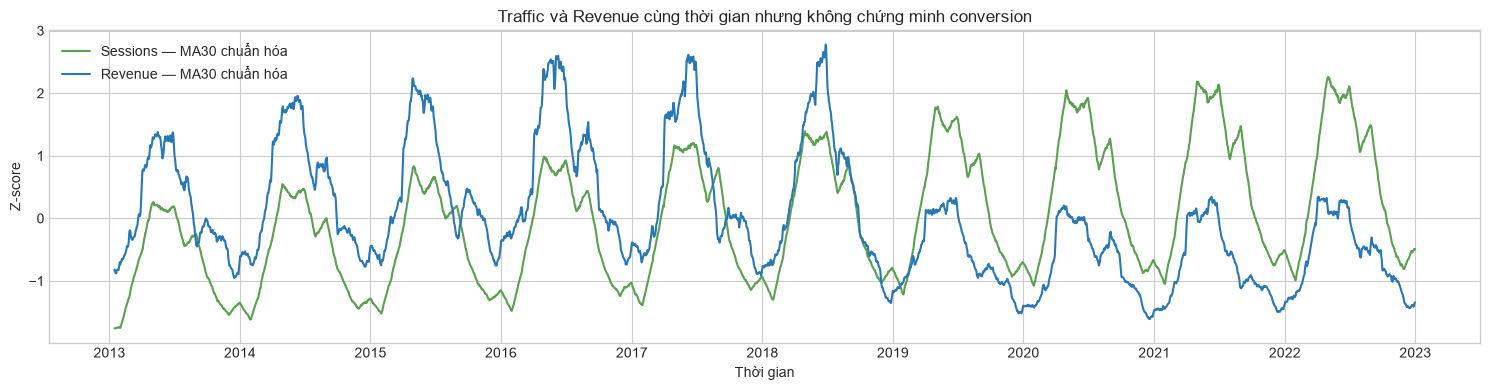

In [13]:
traffic_daily = traffic.merge(sales[['Date','Revenue']],left_on='date',right_on='Date',how='inner')
traffic_corr = traffic_daily[['sessions','unique_visitors','Revenue']].corr().loc[['sessions','unique_visitors'],'Revenue']
proxy_orders_sessions = total_orders/traffic.sessions.sum()
print(f"corr(sessions, Revenue) = {traffic_corr.loc['sessions']:.4f}")
print(f"corr(unique_visitors, Revenue) = {traffic_corr.loc['unique_visitors']:.4f}")
print(f"orders / sessions = {proxy_orders_sessions:.4f} — proxy cấp ngày, KHÔNG phải conversion.")

plot = traffic_daily.set_index('date')[['sessions','Revenue']].rolling(30,min_periods=15).mean()
z = (plot-plot.mean())/plot.std()
fig,ax=plt.subplots(figsize=(15,4))
ax.plot(z.index,z.sessions,label='Sessions — MA30 chuẩn hóa',color=C['green'])
ax.plot(z.index,z.Revenue,label='Revenue — MA30 chuẩn hóa',color=C['blue'])
ax.set(title='Traffic và Revenue cùng thời gian nhưng không chứng minh conversion',
       xlabel='Thời gian',ylabel='Z-score')
ax.legend(); plt.tight_layout(); plt.show()


Traffic chỉ có một dòng/ngày, không có `session_id`, `customer_id` hay `order_id`.
Ghép với sales theo ngày chỉ là căn chỉnh thời gian, không chứng minh conversion hay causality.


## 13. Bức tường 31/12/2022: feature tương lai phải biết trước được

Vùng dự báo bắt đầu 01/01/2023, trong khi mọi bảng phụ dừng trước hoặc đúng 31/12/2022.


Nguồn,Từ ngày,Đến ngày,Số dòng có ngày
orders,2012-07-04,2022-12-31,"646,945"
shipments,2012-07-06,2022-12-31,"566,067"
returns,2012-07-11,2022-12-31,"39,939"
reviews,2012-07-10,2022-12-31,"113,551"
inventory,2012-07-31,2022-12-31,"60,247"
web_traffic,2013-01-01,2022-12-31,"3,652"
sales,2012-07-04,2022-12-31,"3,833"
sample_submission,2023-01-01,2024-07-01,548


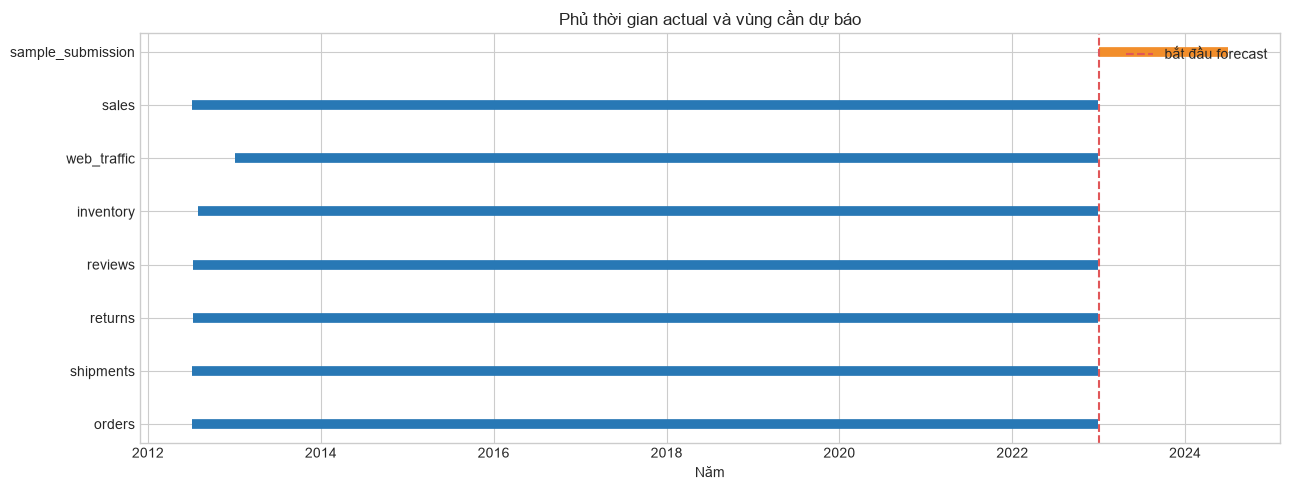

In [14]:
coverage_specs = [
    ('orders','order_date'),('shipments','delivery_date'),('returns','return_date'),
    ('reviews','review_date'),('inventory','snapshot_date'),('web_traffic','date'),
    ('sales','Date'),('sample_submission','Date')
]
coverage=[]
for table,col in coverage_specs:
    s=sources[table][col].dropna()
    coverage.append((table,s.min(),s.max(),len(s)))
coverage_df=pd.DataFrame(coverage,columns=['Nguồn','Từ ngày','Đến ngày','Số dòng có ngày'])
display(coverage_df.style.format({
    'Từ ngày':'{:%Y-%m-%d}','Đến ngày':'{:%Y-%m-%d}','Số dòng có ngày':'{:,.0f}'
}).hide(axis='index'))

fig,ax=plt.subplots(figsize=(13,5))
for i,row in coverage_df.iterrows():
    color=C['orange'] if row.Nguồn=='sample_submission' else C['blue']
    ax.hlines(i,row['Từ ngày'],row['Đến ngày'],lw=7,color=color)
ax.axvline(pd.Timestamp('2023-01-01'),color=C['red'],ls='--',label='bắt đầu forecast')
ax.set_yticks(range(len(coverage_df)),coverage_df.Nguồn)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set(title='Phủ thời gian actual và vùng cần dự báo',xlabel='Năm')
ax.legend(); plt.tight_layout(); plt.show()


Feature dùng được: tháng, ngày trong tháng, năm chẵn/lẻ, khoảng cách tới cuối tháng, cờ scenario Urban Blowout,
lag/rolling chỉ dùng quá khứ.

Không dùng trực tiếp cho 2023–2024 nếu không có nguồn forecast riêng: sessions thực tế, inventory, reviews,
shipments hay promotion chưa được xác nhận.


## 14. Toàn bộ câu chuyện trên một trang


In [15]:
evidence_cards = pd.DataFrame([
    ('Xương sống giao dịch',f'{total_orders:,} orders → {len(items):,} dòng → {int(total_units):,} units','Quan sát'),
    ('Kinh tế',f'Net Sales {total_net/1e9:.3f} tỷ; margin {total_gp/total_net*100:.2f}%','Quan sát'),
    ('Cú gãy 2018→2019',f'Revenue {(annual.loc[2019,"Revenue"]/annual.loc[2018,"Revenue"]-1)*100:.2f}%; orders {(annual.loc[2019,"Orders"]/annual.loc[2018,"Orders"]-1)*100:.2f}%','Driver trực tiếp'),
    ('Mùa vụ',f'Đỉnh/đáy tháng {month_profile.max()/month_profile.min():.2f}×; R² month+day={grouped_r2(["month","day"]):.3f}','Quan sát'),
    ('Urban Blowout',f'T8 năm lẻ thấp hơn {abs((odd.Revenue_index/even.Revenue_index-1)*100):.2f}%; ratio={odd.COGS_Revenue:.3f}','Association mạnh'),
    ('Danh mục',f'{category.index[0]} lớn nhất Net Sales; {category.Margin_pct.idxmax()} cao nhất margin','Quan sát'),
    ('Hậu mãi',f'Return line rate {return_line_rate:.2f}%; rating {reviews.rating.mean():.3f}/5','Quan sát'),
    ('Traffic',f'corr(sessions, Revenue)={traffic_corr.loc["sessions"]:.3f}','Không phải conversion'),
    ('Ranh giới forecast','Actual dừng 2022-12-31; dự báo 548 ngày đến 2024-07-01','Ràng buộc feature')
],columns=['Chương','Bằng chứng cô đọng','Mức kết luận'])
display(evidence_cards.style.hide(axis='index'))


Chương,Bằng chứng cô đọng,Mức kết luận
Xương sống giao dịch,"646,945 orders → 714,669 dòng → 3,213,143 units",Quan sát
Kinh tế,Net Sales 15.681 tỷ; margin 9.68%,Quan sát
Cú gãy 2018→2019,Revenue -38.56%; orders -40.15%,Driver trực tiếp
Mùa vụ,Đỉnh/đáy tháng 2.60×; R² month+day=0.623,Quan sát
Urban Blowout,T8 năm lẻ thấp hơn 37.44%; ratio=1.345,Association mạnh
Danh mục,Streetwear lớn nhất Net Sales; GenZ cao nhất margin,Quan sát
Hậu mãi,Return line rate 5.59%; rating 3.936/5,Quan sát
Traffic,"corr(sessions, Revenue)=0.321",Không phải conversion
Ranh giới forecast,Actual dừng 2022-12-31; dự báo 548 ngày đến 2024-07-01,Ràng buộc feature


## Kết luận: dataset không chỉ hỏi “ngày mai bán được bao nhiêu?”

1. Target tái tạo chính xác từ giao dịch, nên hiểu được cơ chế sinh Revenue và COGS.
2. Doanh nghiệp đổi level cuối 2018; một trend toàn lịch sử sẽ đánh lừa mô hình.
3. Tháng và ngày trong tháng tạo phần lớn nhịp mùa vụ biết trước.
4. Urban Blowout biến tháng 8 năm lẻ thành một chế độ riêng; 2023 cũng là năm lẻ.
5. Quy mô, margin, traffic, fulfillment và hậu mãi trả lời các câu hỏi khác nhau.
6. Tương lai bắt đầu đúng nơi dữ liệu phụ kết thúc; mô hình phải tôn trọng information set lúc forecast.

### Bước modeling hợp lý tiếp theo

- Rolling-origin validation tập trung vào giai đoạn sau 2018.
- So sánh baseline mùa vụ với feature `month`, `day_of_month`, year parity và Urban Blowout scenario.
- Backtest COGS độc lập với phương án `Revenue × predicted_ratio`.
- Báo cáo riêng hiệu năng cho tháng 8 năm lẻ, không chỉ metric trung bình toàn horizon.
- Giữ assumption log cho mọi feature tương lai chưa có nguồn xác nhận.
